<div style="background:#3D2817;color:#FAF7F2;padding:40px;border-radius:4px;font-family:Georgia,serif">

<div style="color:#C7873B;font-size:11px;letter-spacing:3px;font-weight:bold;margin-bottom:8px">
HIGH GARDEN COFFEE  ·  RETO TÉCNICO  ·  ML ENGINEER
</div>

<h1 style="color:#FAF7F2;margin:0;font-size:38px;line-height:1.1;font-weight:bold">
Módulo 1 — Análisis Exploratorio y Storytelling
</h1>

<p style="color:#D4C9B8;font-size:14px;font-style:italic;margin-top:12px;line-height:1.5">
El consumo doméstico de los países productores de café, leído como inteligencia
competitiva para una empresa exportadora internacional.
</p>

<div style="margin-top:24px;font-size:11px;color:#C7873B">
PARTE 1 DE 5  ·  ANÁLISIS DE LA INFORMACIÓN
</div>

</div>

## Mapa del módulo

| Sección | Contenido |
|---|---|
| **1.** | El problema reformulado — hipótesis central, evidencias y reframing estratégico |
| **2.** | Carga del dataset y auditoría de integridad |
| **3.** | Preparación de datos: long format, enriquecimiento regional, métricas derivadas |
| **4.** | Siete lentes analíticas con narrativa y visualizaciones editoriales |
| **5.** | Síntesis ejecutiva y handoff al módulo de modelado |

---

## 1 · El problema reformulado

> **Tesis central**
>
> *El dataset no representa el mercado consumidor global de café, sino el consumo interno de los países productores. Aplicada al contexto de una empresa exportadora, esta lectura transforma el problema de un ejercicio descriptivo a uno de inteligencia competitiva sobre la oferta exportable mundial.*

### Corolario estratégico

Cada unidad de café consumida internamente por un país productor es una unidad que **no entra al mercado de exportación**. Por lo tanto:

- El consumo doméstico de productores es un **indicador adelantado de la oferta exportable global**
- Su crecimiento sostenido implica **presión estructural al alza sobre los precios internacionales**
- Para una exportadora como High Garden Coffee, anticipar este comportamiento es **ventaja competitiva directa**

### Cadena de evidencia que sustenta la hipótesis

**Evidencia 1 — Composición de la muestra.** Los 55 países del dataset son, sin excepción, países productores. Los principales países consumidores del mundo están **ausentes**. Esta ausencia es imposible en un dataset de "mercado global" y esperada en un dataset de "consumo de productores":

In [15]:
import pandas as pd

df_raw = pd.read_parquet('./data/coffee_db.parquet')
countries = set(df_raw['Country'].tolist())

top_consumers = ['United States','Germany','France','Italy','Japan',
                 'United Kingdom','Canada','Spain','Netherlands','Belgium']
top_producers = ['Brazil','Viet Nam','Colombia','Indonesia','Ethiopia',
                 'Honduras','India','Uganda','Mexico','Guatemala']

evidence = pd.DataFrame({
    'Top consumidores mundiales': [c for c in top_consumers] + [None]*0,
    '¿En dataset?': ['❌ NO' if c not in countries else '✓ SÍ' for c in top_consumers],
    'Top productores mundiales': top_producers,
    '¿En dataset?.1': ['✓ SÍ' if c in countries else '❌ NO' for c in top_producers],
})
evidence

,Top consumidores mundiales,¿En dataset?,Top productores mundiales,¿En dataset?.1
0,United States,❌ NO,Brazil,✓ SÍ
1,Germany,❌ NO,Viet Nam,✓ SÍ
2,France,❌ NO,Colombia,✓ SÍ
3,Italy,❌ NO,Indonesia,✓ SÍ
4,Japan,❌ NO,Ethiopia,✓ SÍ
5,United Kingdom,❌ NO,Honduras,✓ SÍ
6,Canada,❌ NO,India,✓ SÍ
7,Spain,❌ NO,Uganda,✓ SÍ
8,Netherlands,❌ NO,Mexico,✓ SÍ
9,Belgium,❌ NO,Guatemala,✓ SÍ


**Evidencia 2 — Convenciones técnicas del dataset:**

| Pista | Lectura industrial |
|---|---|
| Formato de año `1990/91` | "Coffee year" oficial (octubre–septiembre). Exclusivo de la industria cafetera profesional |
| Columna `Coffee type` con Arabica/Robusta | Tiene sentido solo desde el lado productor — cada país cultiva uno u otro o ambos |
| Cifras como múltiplos de 60,000 | 60 kg es el saco estándar de café — sugiere conversión sacos→tazas con factor fijo |
| Granularidad país × tipo × año | Estructura típica de los reportes de la ICO (International Coffee Organization) |

**Evidencia 3 — Validación documental con la ICO:**

La ICO publica oficialmente un dataset con exactamente estas características (54 países productores, mismo formato, misma granularidad). Más importante aún, la propia ICO documenta el mecanismo que sostiene nuestra tesis estratégica:

> *"El creciente consumo doméstico de café en los países exportadores actuará como un factor significativo en la determinación de los precios globales."* — ICO

> *"Dada la proporción de producción requerida para satisfacer la demanda doméstica en países exportadores, los aumentos en producción tendrán impacto limitado sobre el balance oferta-demanda."* — ICO

**Evidencia 4 — Caso de validación: Etiopía.** Quinto productor mundial pero solo noveno exportador, porque consume internamente cerca del 50% de su cosecha. Esto valida el mecanismo en un caso medible.

---

## 2 · Carga del dataset y auditoría de integridad

Antes de cualquier análisis: integridad estructural. Cinco chequeos formales con resultados documentados.

In [16]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd

# Cargar el dataset original
df = pd.read_parquet('./data/coffee_db.parquet')
df.columns = df.columns.str.strip()

year_cols = [c for c in df.columns if '/' in c]

print(f"Estructura : {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Países     : {df['Country'].nunique()}")
print(f"Período    : {year_cols[0]} → {year_cols[-1]} ({len(year_cols)} años)")
print(f"Tipos café : {df['Coffee type'].value_counts().to_dict()}")

Estructura : 55 filas × 33 columnas
Países     : 55
Período    : 1990/91 → 2019/20 (30 años)
Tipos café : {'Arabica': 22, 'Robusta': 15, 'Robusta/Arabica': 10, 'Arabica/Robusta': 8}


### Cinco validaciones críticas

In [17]:
# 1. NULOS
n_nulls = df.isnull().sum().sum()

# 2. DUPLICADOS de país-tipo
n_dups = df.duplicated(subset=['Country','Coffee type']).sum()

# 3. CONSISTENCIA: ¿la columna Total_domestic_consumption coincide
#    con la suma de los años anuales? (audit de integridad interna)
computed_total = df[year_cols].sum(axis=1)
given_total = df['Total_domestic_consumption']
max_diff_pct = ((computed_total - given_total).abs() / given_total.replace(0,np.nan) * 100).max()

# 4. CEROS: ¿qué países tienen ceros en al menos un año?
has_zero = (df[year_cols] == 0).any(axis=1)
countries_with_zeros = df.loc[has_zero, 'Country'].tolist()

# 5. RANGO: ¿hay valores negativos? (no debería haberlos)
n_negative = (df[year_cols] < 0).sum().sum()

report = pd.DataFrame([
    ['Nulos totales',                    n_nulls,                   '✓ pasa' if n_nulls == 0 else '✗ falla'],
    ['Duplicados país-tipo',             n_dups,                    '✓ pasa' if n_dups == 0 else '✗ falla'],
    ['Max % diferencia total computado vs dado', f'{max_diff_pct:.4f}%', '✓ pasa' if max_diff_pct < 0.01 else '✗ revisar'],
    ['Países con ≥1 año en cero',        len(countries_with_zeros), '⚠ tratar en modelado'],
    ['Valores negativos',                n_negative,                '✓ pasa' if n_negative == 0 else '✗ falla'],
], columns=['Validación', 'Resultado', 'Estado'])
report

,Validación,Resultado,Estado
0,Nulos totales,0,✓ pasa
1,Duplicados país-tipo,0,✓ pasa
2,Max % diferencia total computado vs dado,0.0000%,✓ pasa
3,Países con ≥1 año en cero,7,⚠ tratar en modelado
4,Valores negativos,0,✓ pasa


**Lectura del informe de validación:**

- **Cero nulos, cero duplicados.** El dataset llega impecablemente curado en términos de completitud.
- **Consistencia interna perfecta** entre la columna `Total_domestic_consumption` y la suma de los años. Es un dataset agregado, no construido a partir de muestreo.
- **7 países con ceros en al menos un año** (Equatorial Guinea, Nepal, Yemen, Lao PDR, Guyana, Timor-Leste, Zambia). Esto no es necesariamente error — algunos países simplemente no reportaron consumo en ciertos años o efectivamente fue marginal. Lo documentamos para tratamiento explícito en los módulos de modelado.

---

## 3 · Preparación: long format, regiones y métricas derivadas

Dos formatos son útiles según la tarea:

- **Wide** (formato original, 1 fila por país-tipo): cómodo para comparaciones country-level
- **Long** (1 fila por país-tipo-año): obligatorio para análisis temporales y modelado de series

Adicionalmente, enriquecemos con:
- Mapeo país → región/subregión (geografía del cinturón cafetero)
- Crecimiento año-a-año (`yoy_growth_pct`)
- Métricas resumen: media, σ, coeficiente de variación
- CAGR en dos ventanas (1990-2005 y 2005-2020) para detectar cambios de régimen
- Share global de cada país en años clave

In [18]:
# El módulo data_prep encapsula toda esta lógica
sys.path.insert(0, '.')
from data_prep import REGION_MAP, to_long, enrich

long = to_long(df)
long, wide = enrich(long, df)

print(f"Long  : {long.shape}  ·  Columnas: {long.columns.tolist()}")
print(f"Wide  : {wide.shape}  ·  Nuevas columnas: {[c for c in wide.columns if c not in df.columns]}")


Long  : (1650, 8)  ·  Columnas: ['Country', 'Coffee type', 'coffee_year', 'consumption_cups', 'year', 'region', 'subregion', 'yoy_growth_pct']
Wide  : (55, 44)  ·  Nuevas columnas: ['region', 'subregion', 'mean_consumption', 'std_consumption', 'cv_consumption', 'cagr_1990_2005', 'cagr_2005_2020', 'cagr_full', 'share_1990', 'share_2020', 'share_change']


In [19]:
# Vista del long format enriquecido
long.head(8)

,Country,Coffee type,coffee_year,consumption_cups,year,region,subregion,yoy_growth_pct
0,Angola,Robusta/Arabica,1990/91,1200000.0,1990,Africa,Southern Africa,NaN
55,Angola,Robusta/Arabica,1991/92,1800000.0,1991,Africa,Southern Africa,50.000000
110,Angola,Robusta/Arabica,1992/93,2100000.0,1992,Africa,Southern Africa,16.666667
165,Angola,Robusta/Arabica,1993/94,1200000.0,1993,Africa,Southern Africa,-42.857143
220,Angola,Robusta/Arabica,1994/95,1500000.0,1994,Africa,Southern Africa,25.000000
275,Angola,Robusta/Arabica,1995/96,600000.0,1995,Africa,Southern Africa,-60.000000
330,Angola,Robusta/Arabica,1996/97,1200000.0,1996,Africa,Southern Africa,100.000000
385,Angola,Robusta/Arabica,1997/98,2400000.0,1997,Africa,Southern Africa,100.000000


### Persistencia de los datos preparados

Guardamos los datasets preparados en `data/` para que los módulos siguientes los consuman directamente, sin tener que ejecutar `data_prep.py` manualmente. Este notebook es **autosuficiente**: al ejecutarlo de principio a fin, genera todo lo necesario para los módulos posteriores.

In [20]:
import json
from pathlib import Path

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

# Validation report como JSON
validation_data = {
    "shape": list(df.shape),
    "n_countries": int(df["Country"].nunique()),
    "n_years": int(len(year_cols)),
    "period": f"{year_cols[0]} -> {year_cols[-1]}",
    "coffee_types": df["Coffee type"].value_counts().to_dict(),
    "nulls": int(df.isnull().sum().sum()),
    "duplicates_country_type": int(df.duplicated(subset=["Country","Coffee type"]).sum()),
    "total_consistency_max_pct_diff": float(max_diff_pct),
    "countries_with_zeros": countries_with_zeros,
    "negative_values": int(n_negative),
}

# Guardar los tres artefactos
long.to_parquet(DATA_DIR / 'coffee_long.parquet', index=False)
wide.to_parquet(DATA_DIR / 'coffee_wide.parquet', index=False)
with open(DATA_DIR / 'validation_report.json', 'w') as f:
    json.dump(validation_data, f, indent=2, default=str)

print('Datos preparados guardados en data/:')
print(f'  coffee_long.parquet     ({long.shape[0]} filas)')
print(f'  coffee_wide.parquet     ({wide.shape[0]} filas)')
print(f'  validation_report.json')

Datos preparados guardados en data/:
  coffee_long.parquet     (1650 filas)
  coffee_wide.parquet     (55 filas)
  validation_report.json


## 4 · Siete lentes para entender el dataset

Cada visualización siguiente responde a una pregunta de negocio. No son gráficas descriptivas — son **herramientas de decisión**.

| # | Pregunta | Tesis que defiende |
|---|---|---|
| 4.1 | ¿Cómo evolucionó la demanda doméstica global? | El consumo se multiplicó por 2.6 en 30 años |
| 4.2 | ¿Se diversificó el mercado o se concentró? | Se concentró — el mito emergente es parcial |
| 4.3 | ¿Cómo clasificamos a cada país estratégicamente? | El cuadrante de aceleración separa ganadores de perdedores |
| 4.4 | ¿Existe un patrón temporal por país? | El ADN visual revela estructuras escondidas |
| 4.5 | ¿Crecieron todas las regiones igual? | No — Asia 4.2×, Caribbean 1.2× |
| 4.6 | ¿Cambió la composición Arabica/Robusta? | Robusta/Arabica ganó terreno relevante |
| 4.7 | ¿Qué tan predecible es cada mercado? | Define qué modelos usar en el Módulo 2 |

### Configuración del sistema de visualización

Sistema editorial reutilizable definido en `style.py` — tipografía serif, paleta café cohesiva, kicker + título + tesis + fuente.

In [21]:
import sys; sys.path.insert(0, '.')
from style import apply_style
from eda_viz import (fig1_macro_story, fig2_concentration, fig3_acceleration_quadrant,
                     fig4_heatmap, fig5_regional_story, fig6_coffee_type, fig7_volatility_size)
from IPython.display import Image, display

apply_style()
print("Sistema de visualización inicializado")

Sistema de visualización inicializado


---

### 4.1 La historia macro: el consumo se multiplicó por 2.6

**Pregunta:** ¿Qué tan grande es el cambio en el consumo doméstico de los productores en 30 años?

El crecimiento es **estructural y sostenido**, no cíclico. Tres décadas de aumento ininterrumpido apenas matizadas por la primera contracción del período en 2019/20 (pandemia).

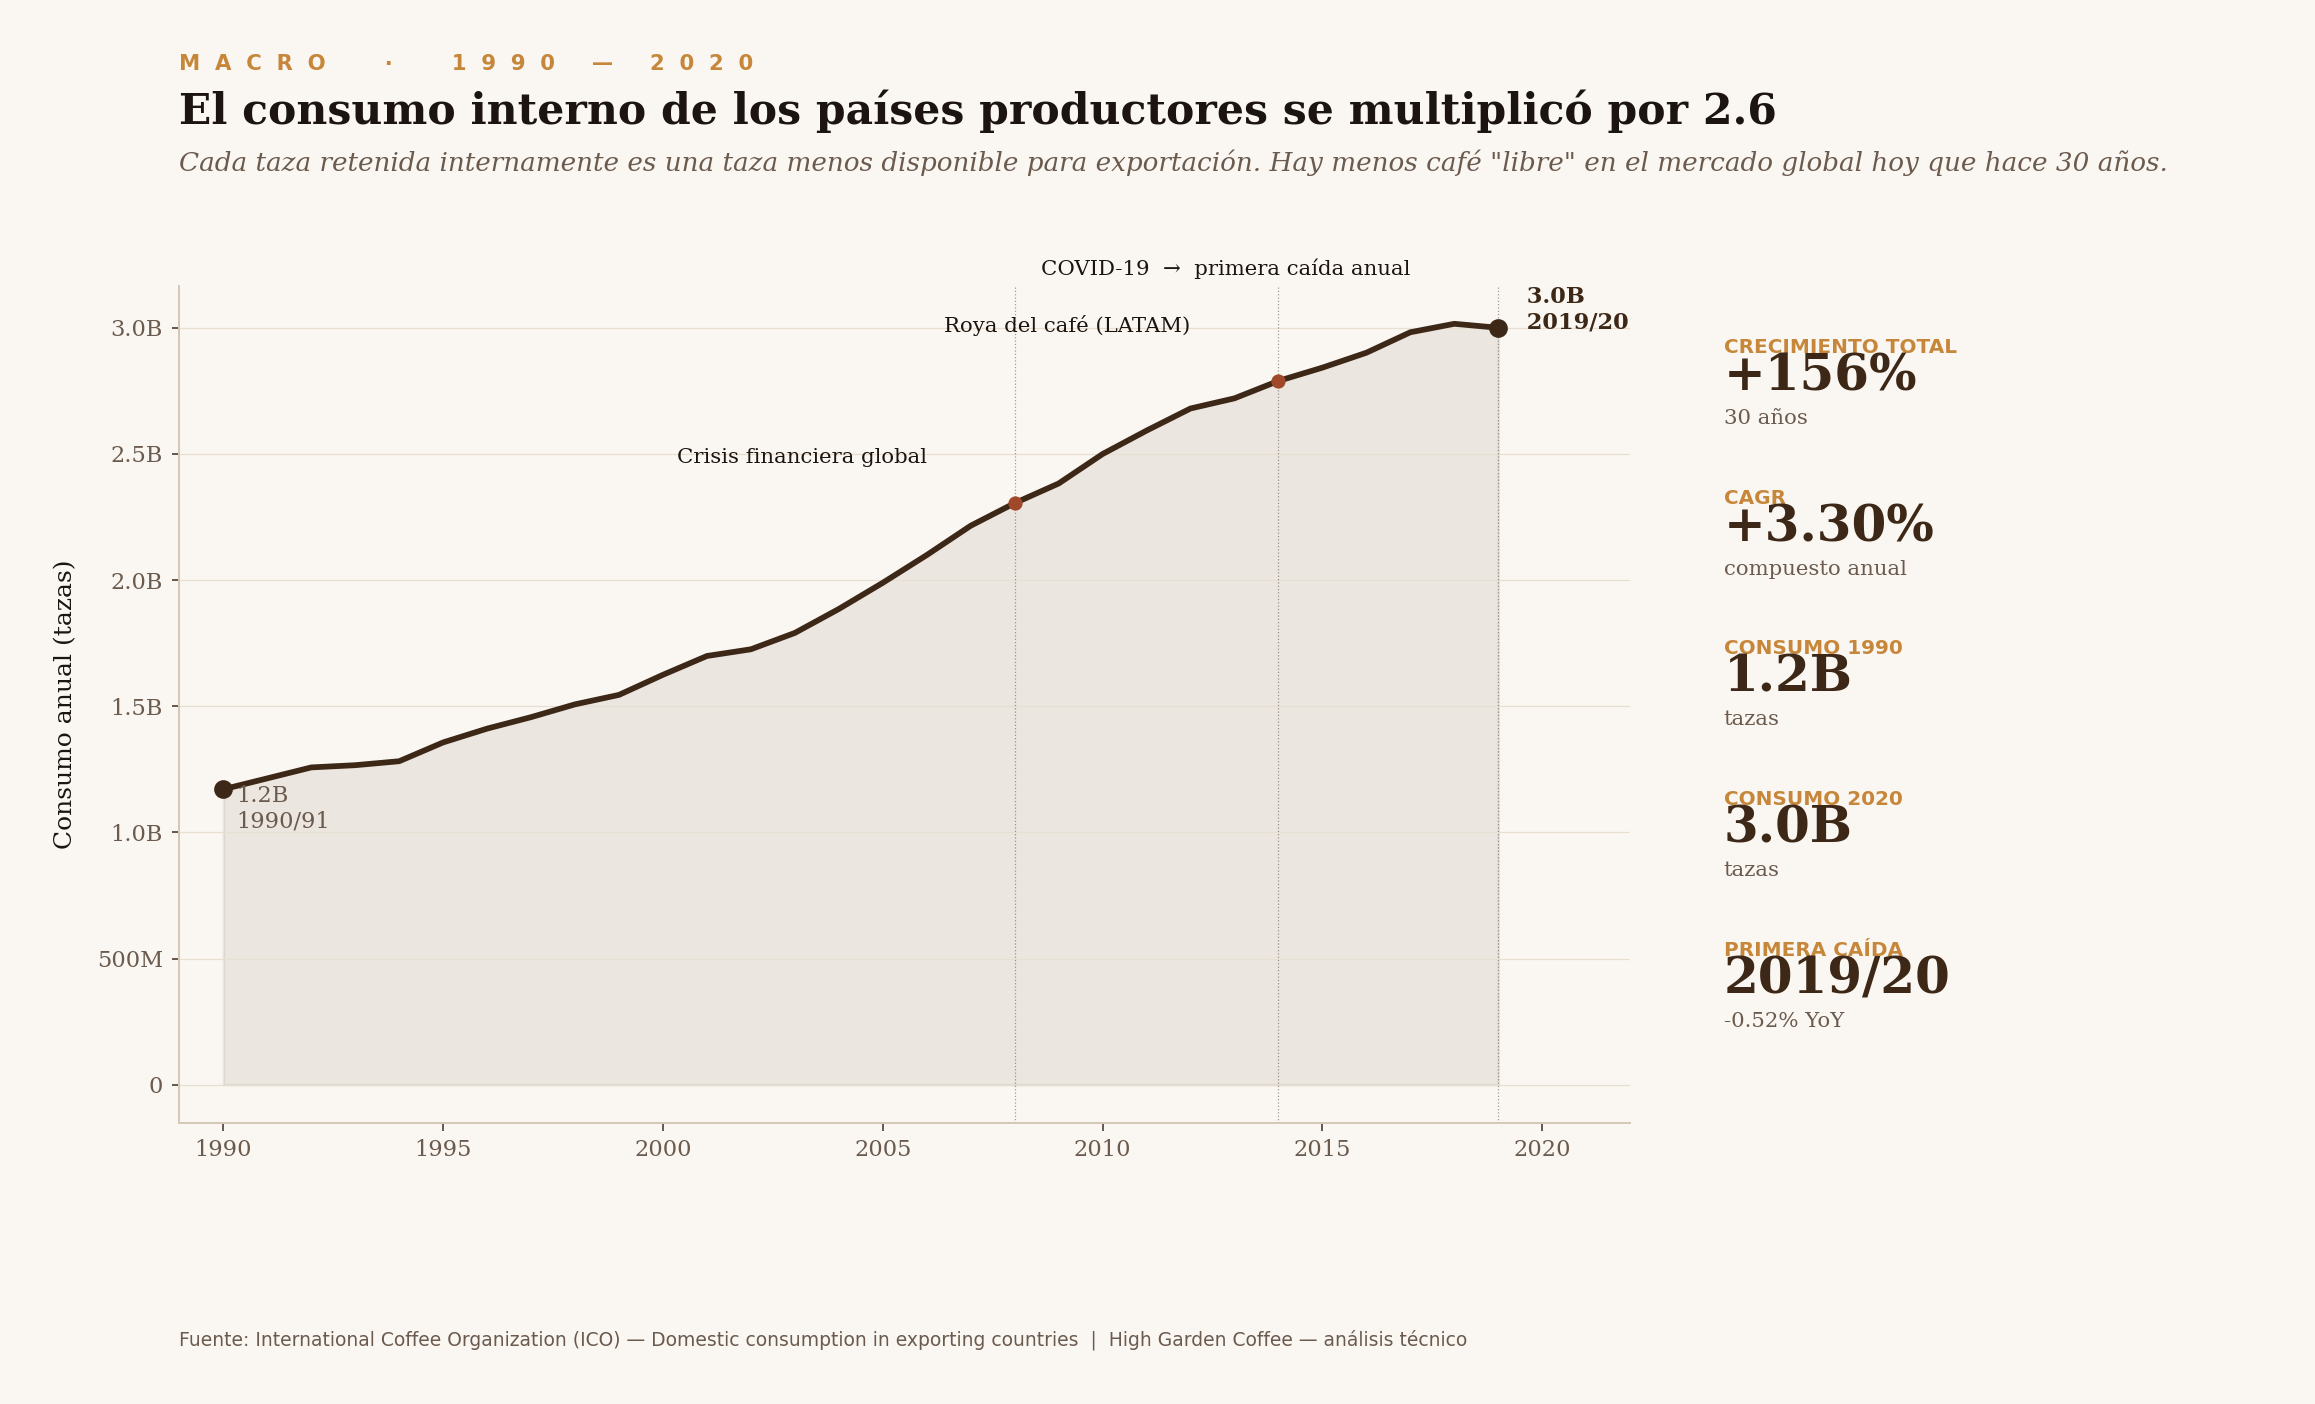

In [22]:
fig1_macro_story(long)
display(Image('./figures/01_macro_story.png'))

**Lectura de negocio:**

- **+156% en 30 años** equivale a un CAGR del **3.30%** — más rápido que el crecimiento poblacional de la mayoría de estos países, lo que sugiere **mayor consumo per cápita**, no solo "más gente"
- **2019/20 es la primera caída en la serie completa** (-0.52%). Vale identificar después qué países la lideraron
- Los hitos de la crisis financiera 2008 y la roya del café 2014 son visibles como inflexiones suaves, no como shocks estructurales — el consumo doméstico es **más resiliente** que el comercio internacional

**Implicación para High Garden Coffee:** cada año, una fracción creciente del café producido se queda en origen. El mercado exportable, en términos relativos, se está estrechando.

---

### 4.2 El mercado se está concentrando, no diversificando

**Pregunta:** El crecimiento de los "emergentes" (Vietnam, Indonesia, Filipinas) ¿está reduciendo la concentración del mercado?

**Hallazgo contraintuitivo:** No. El Índice Herfindahl-Hirschman subió **+216 puntos** en el período, indicando **mayor concentración**. Brasil incluso amplió su dominancia del 42% al 44%.

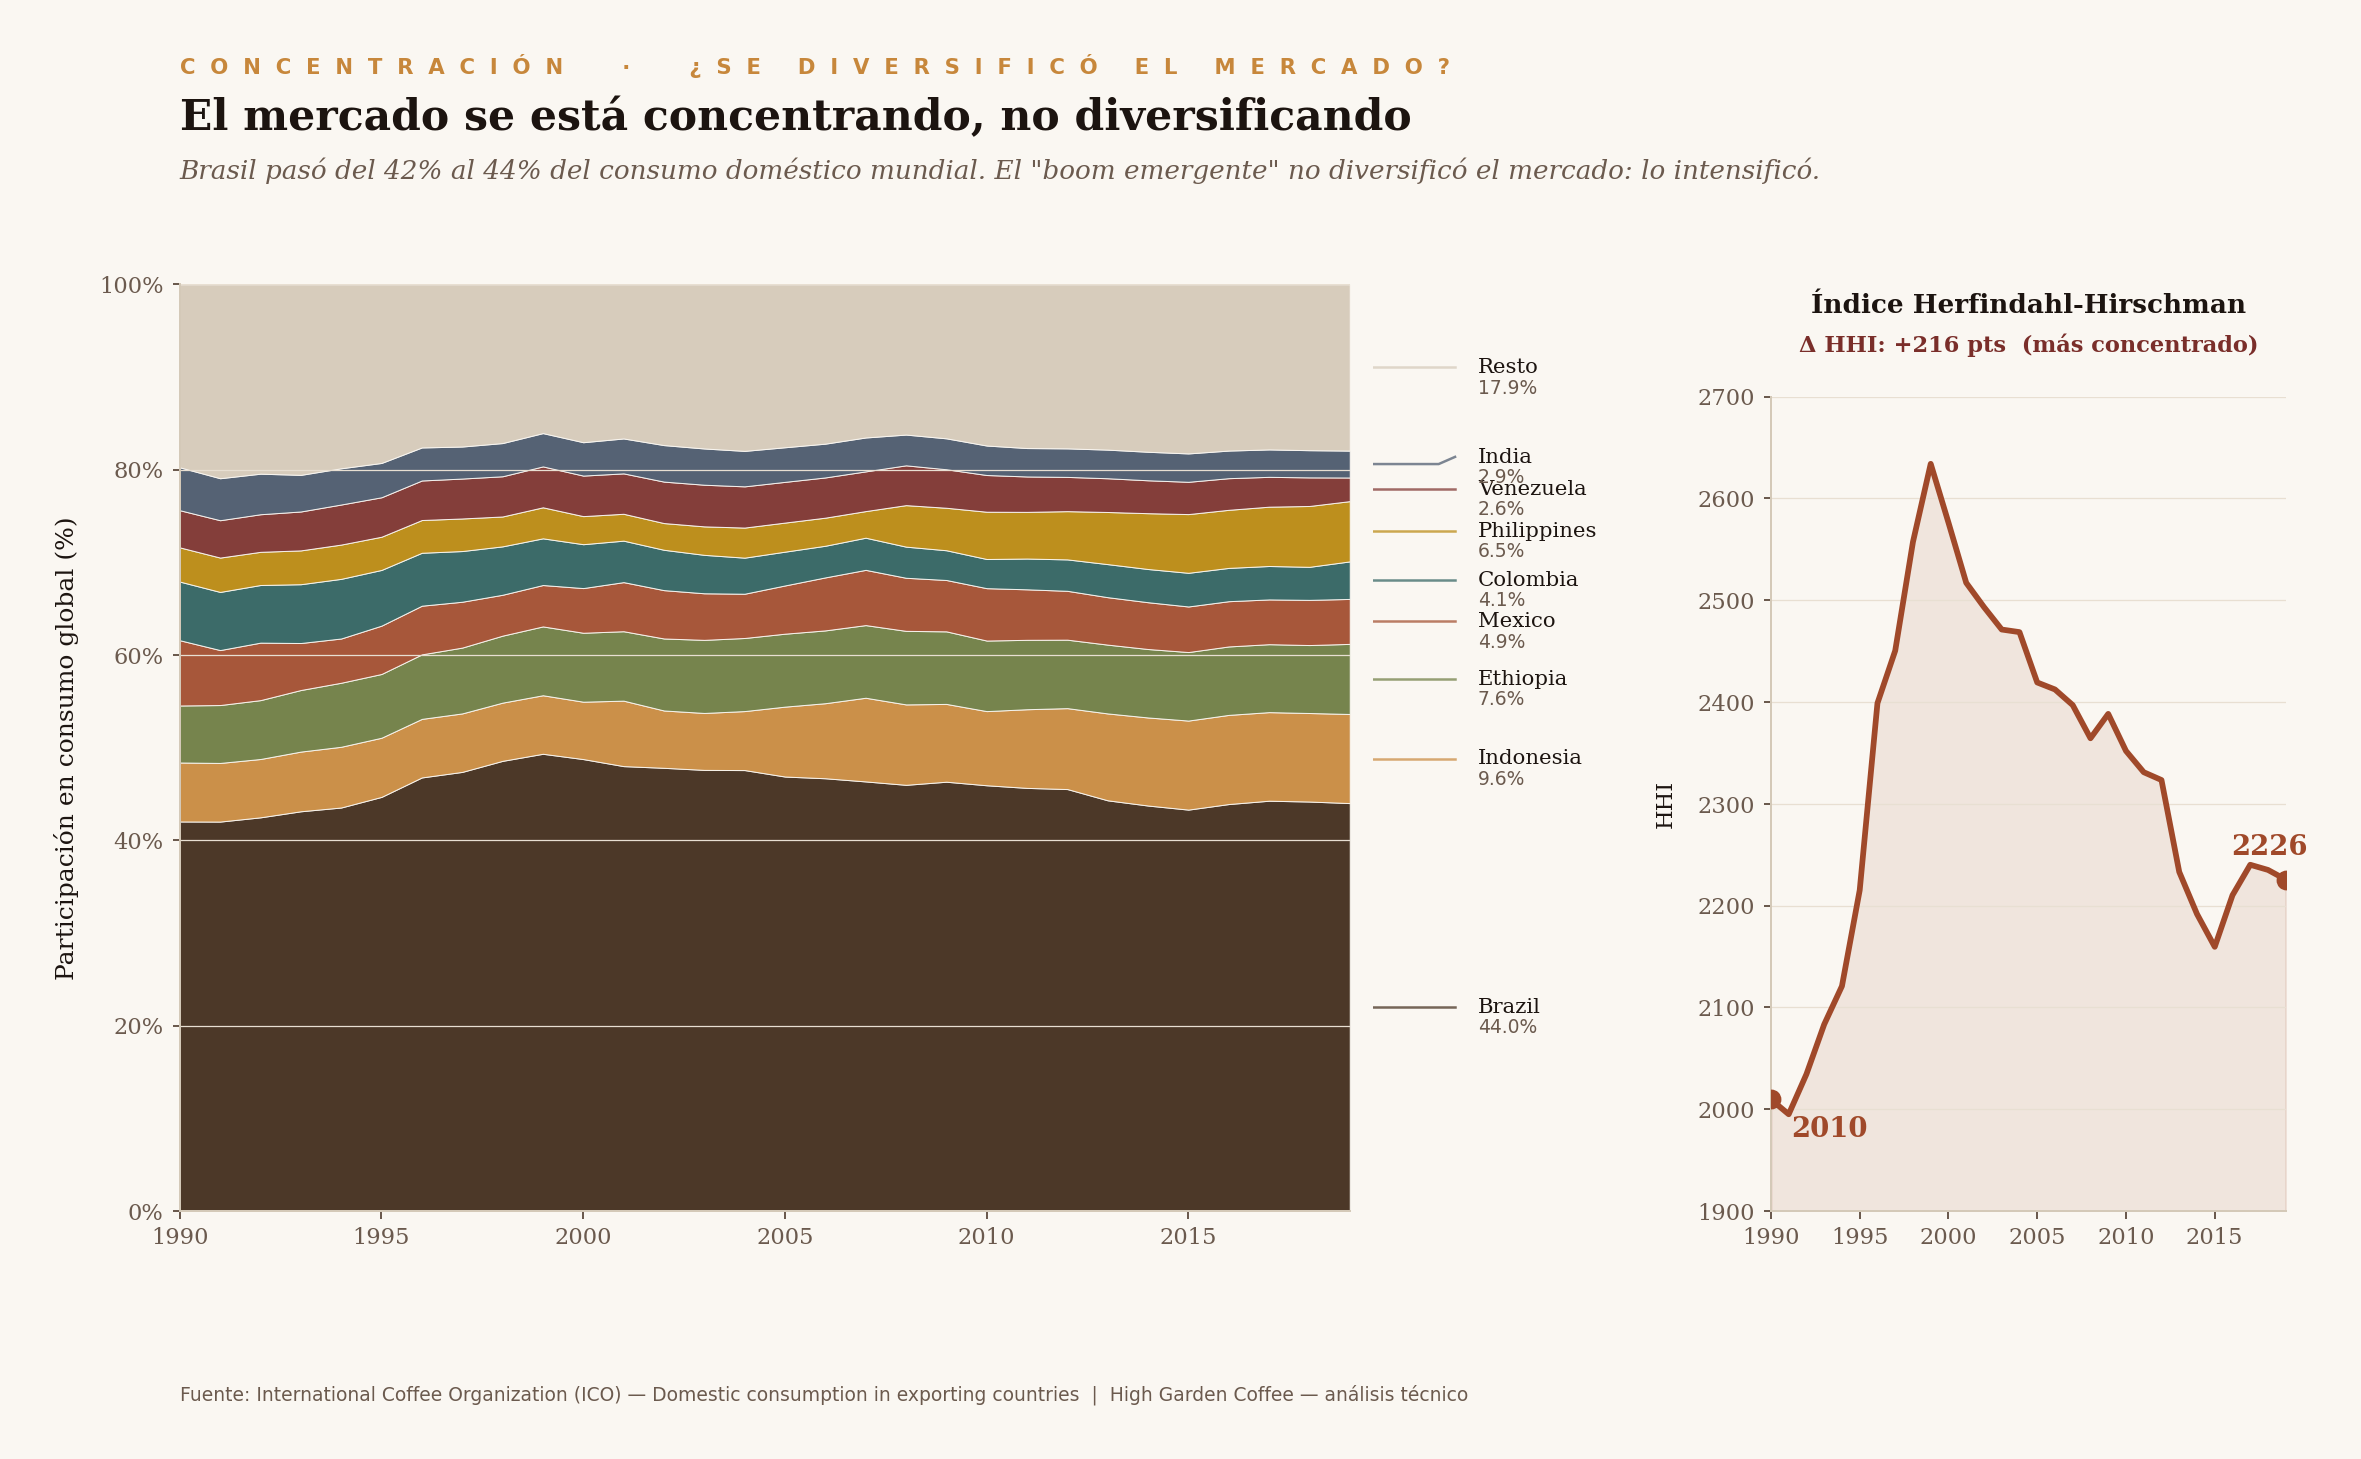

In [23]:
fig2_concentration(long, wide)
display(Image('figures/02_concentration.png'))

**Lectura técnica:**

- El HHI pasó de **2,010 → 2,226** (umbral de "alta concentración" según directrices antitrust = 2,500)
- El "boom emergente" creció sobre la base total, **no a costa** de Brasil — el oligopolio se intensificó
- Aunque Vietnam multiplicó su consumo doméstico 10×, sigue siendo menor al 4% del total mundial

**Implicación para High Garden Coffee:** la estrategia con Brasil no es opcional. Es **la mitad del mercado** y cualquier movimiento allí tiene impacto desproporcionado.

---

### 4.3 El cuadrante de aceleración — la gráfica "money"

**Pregunta:** ¿Cómo clasificamos cada país según su trayectoria histórica?

Comparamos dos ventanas de CAGR (1990-2005 vs 2005-2020). El resultado son cuatro arquetipos accionables:

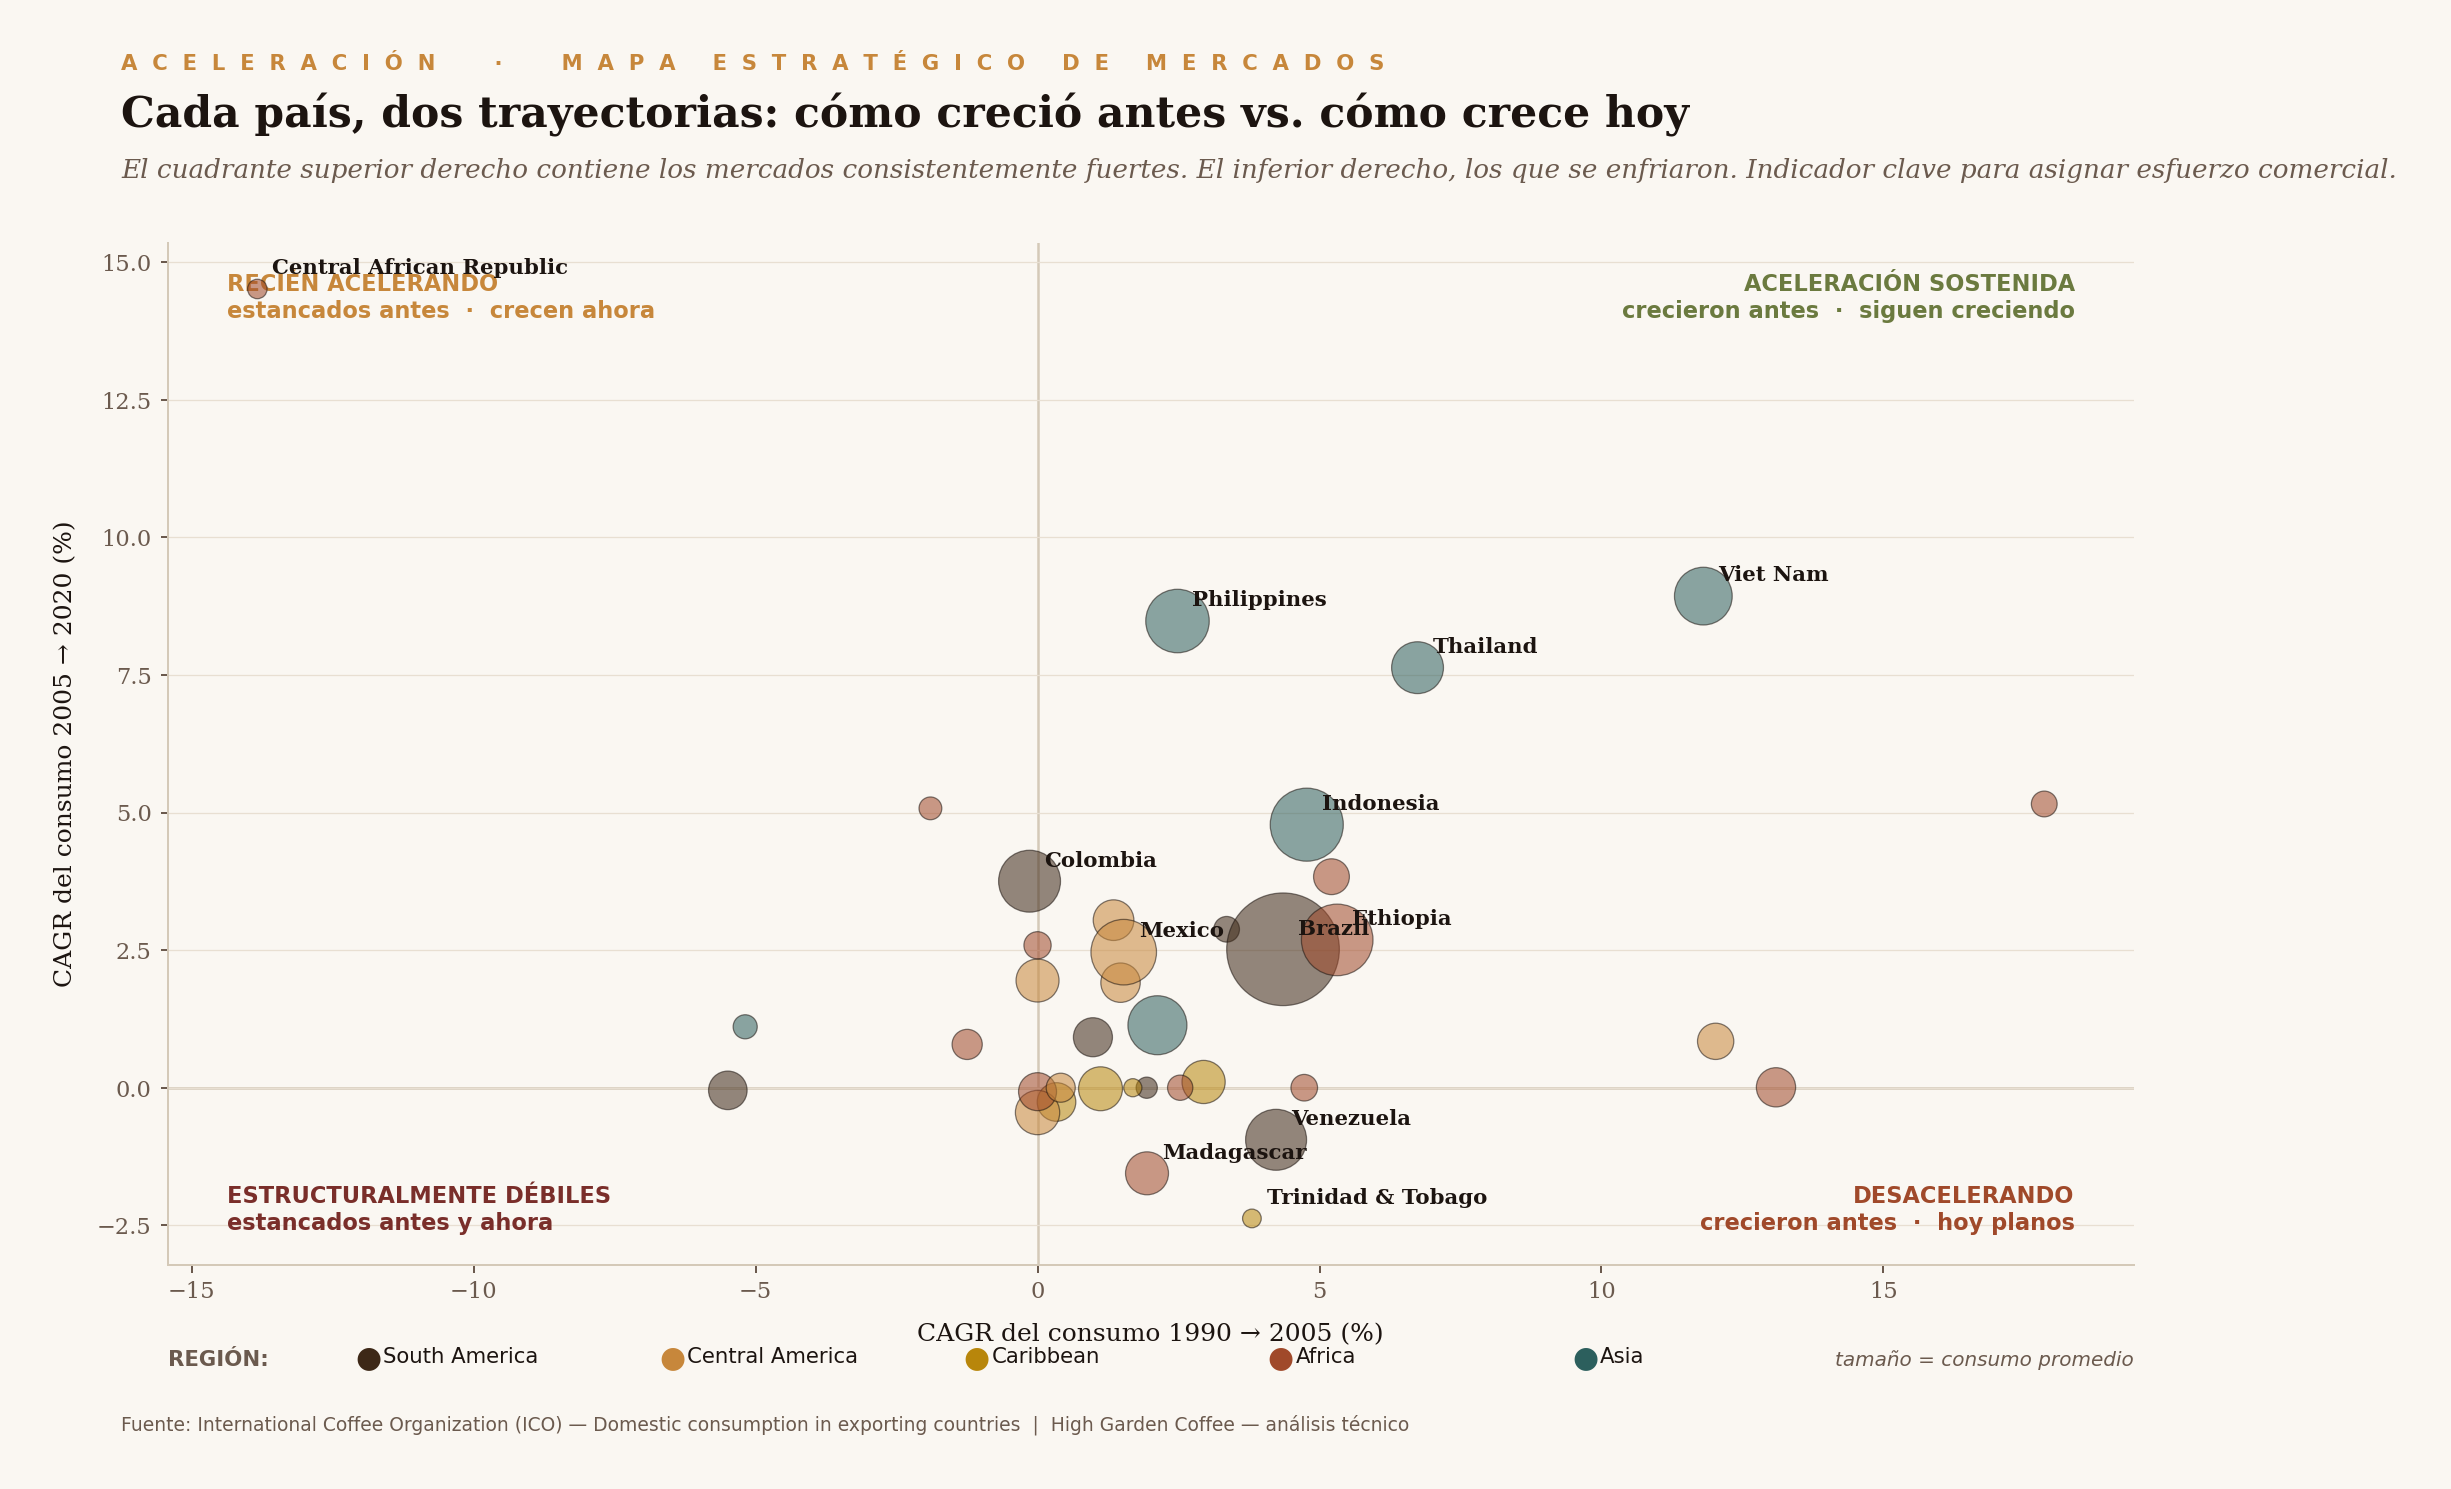

In [24]:
fig3_acceleration_quadrant(wide)
display(Image('figures/03_acceleration_quadrant.png'))

**Los cuatro arquetipos identificados:**

| Cuadrante | Países representativos | Implicación comercial |
|---|---|---|
| **Aceleración sostenida** (↗ y ↗) | Vietnam, Thailand, Indonesia | Mercados a abastecer; competirán por su propio café |
| **Recién acelerando** (→ y ↗) | Philippines, Central African Republic | Oportunidad fresca; subir prioridad |
| **Desacelerando** (↗ y →) | Côte d'Ivoire, Nicaragua, Tanzania | Crecimiento agotado; revisar exposición |
| **Estructuralmente débiles** (→ y →/↘) | Madagascar, Venezuela | Menor prioridad estratégica |

**Implicación clave para forecasting (Módulo 2):** los países "desacelerando" tienen **quiebres estructurales** en su serie temporal. Un modelo que use los 30 años completos sobreestimará sistemáticamente su crecimiento futuro. Hay que detectar el quiebre y modelar solo el régimen vigente.

---

### 4.4 El ADN del crecimiento — heatmap por país y época

**Pregunta:** ¿Existe un patrón visual que revele estructuras escondidas?

Normalizamos cada país a su propio máximo (0-100%). Esto revela la **forma** del crecimiento, no el nivel: explosivo, gradual, estancado o regresivo.

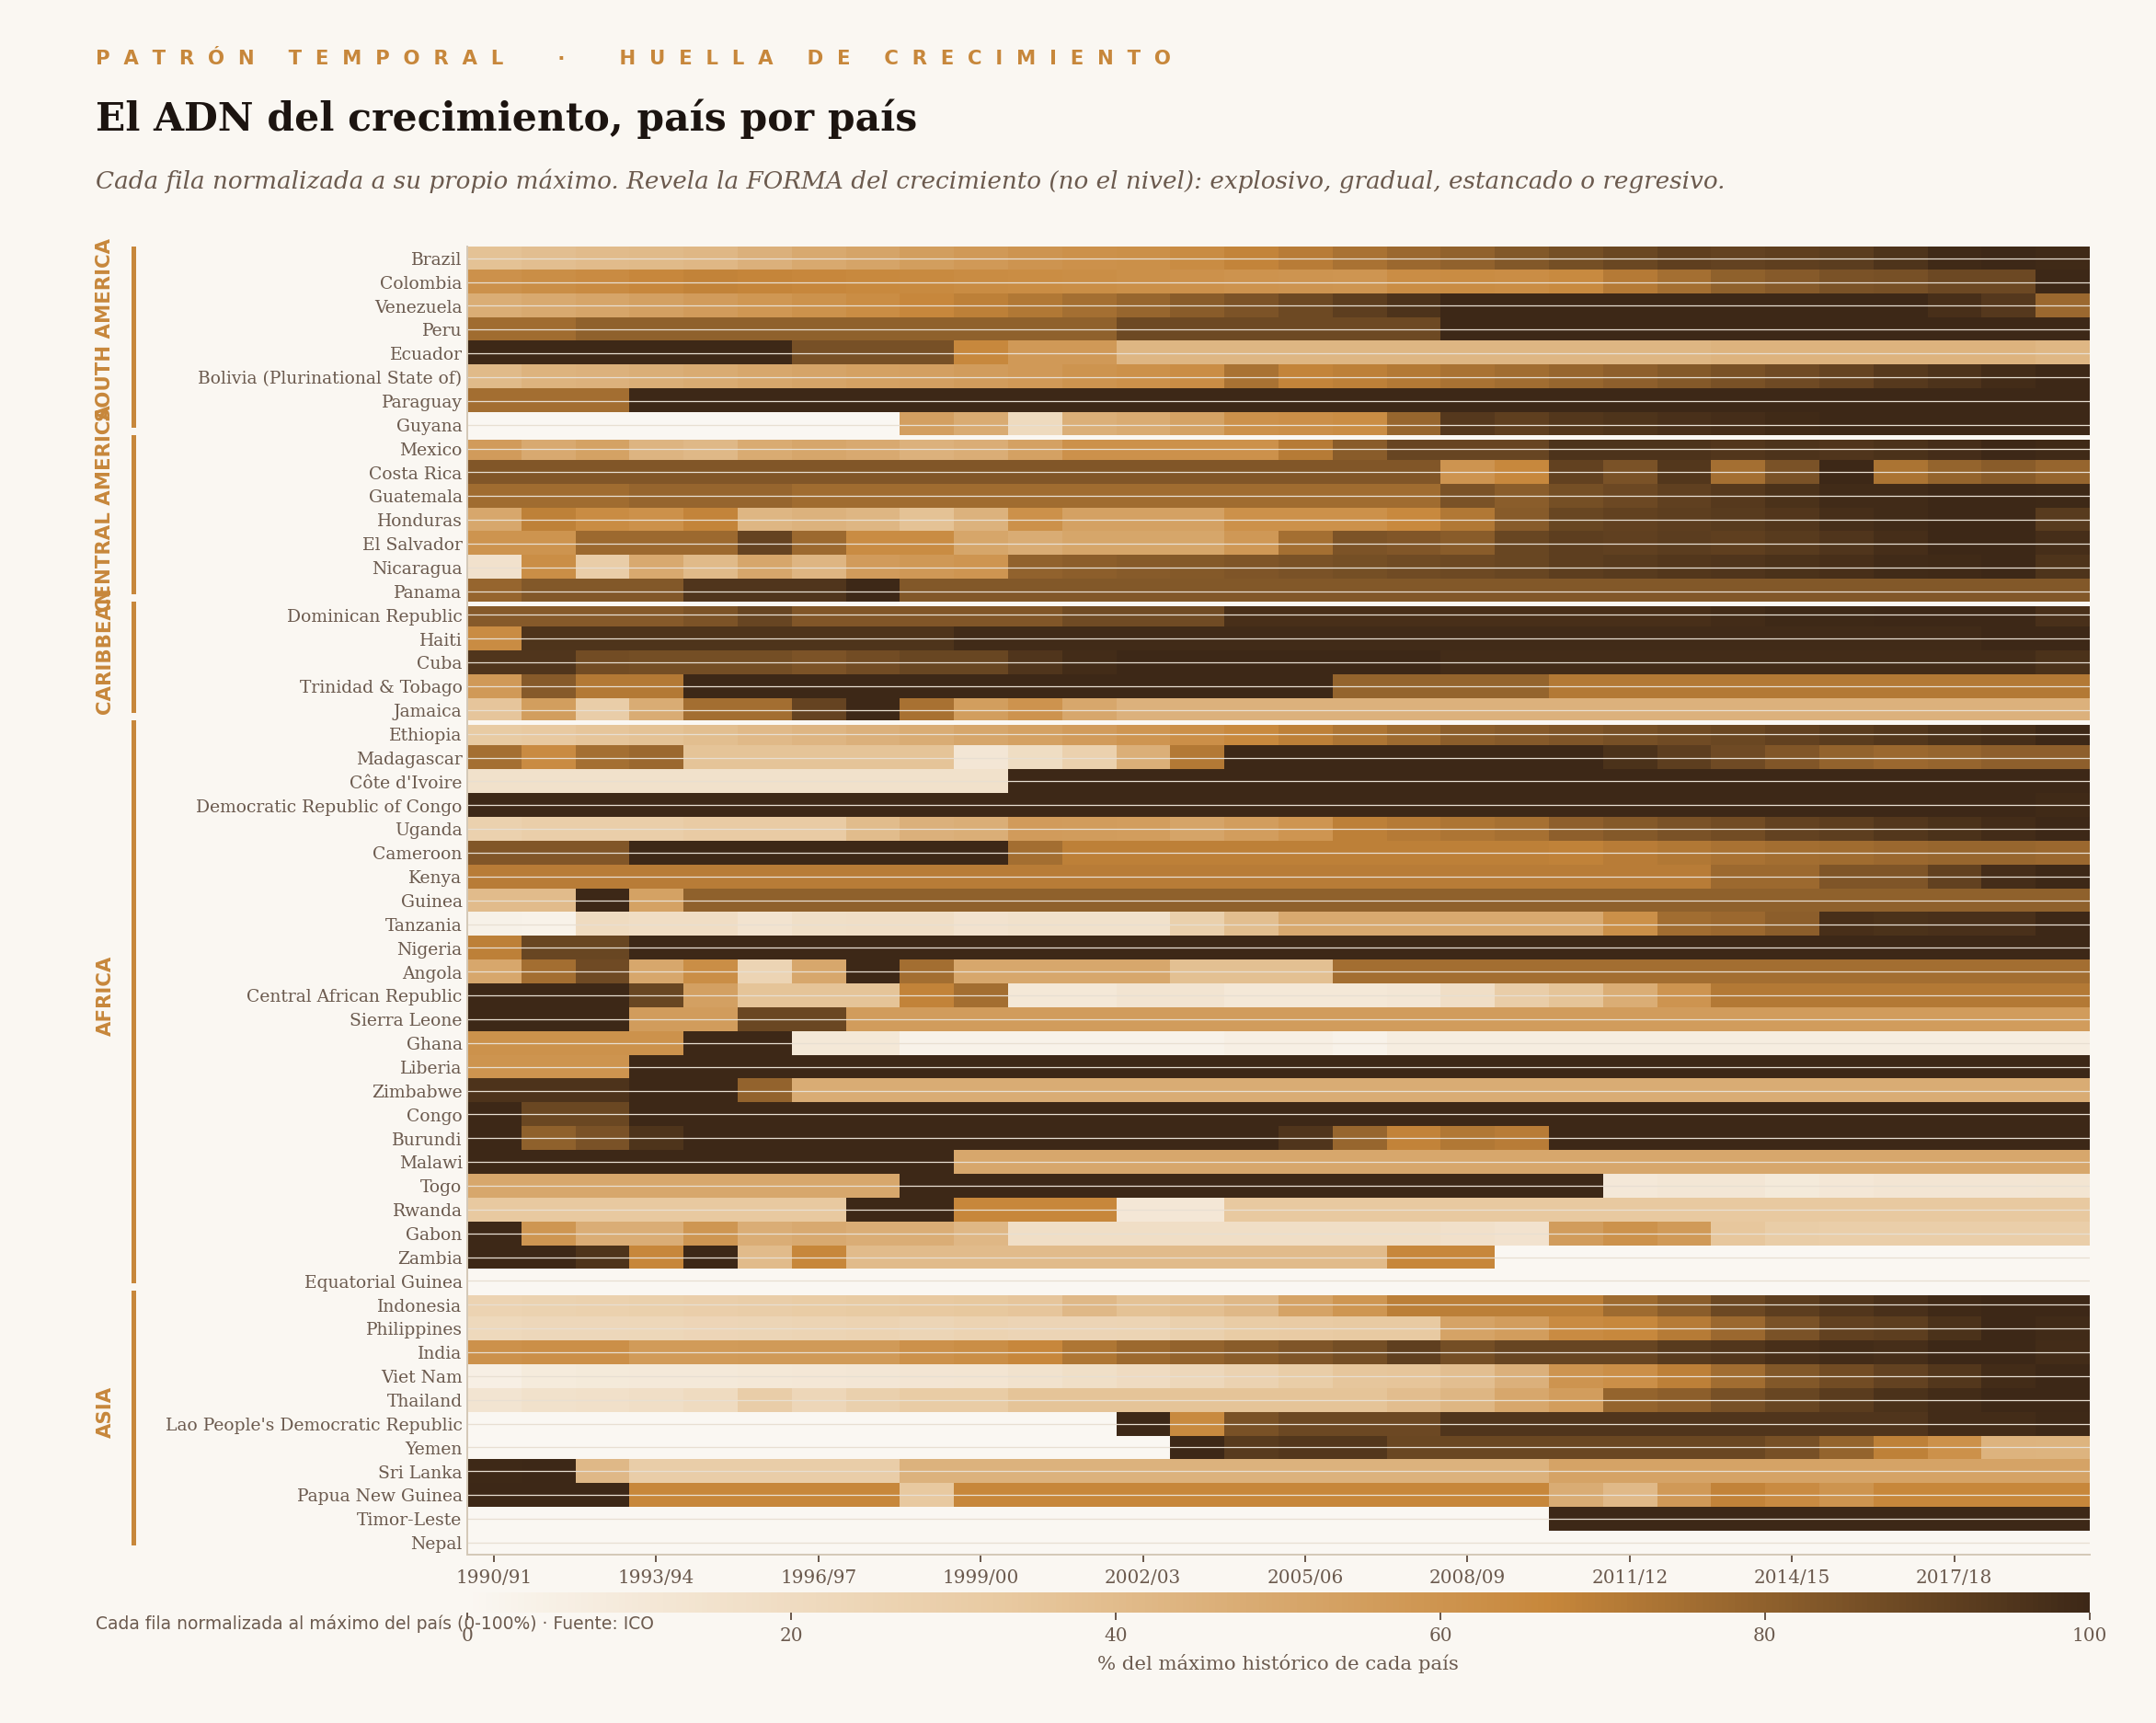

In [25]:
fig4_heatmap(long, wide)
display(Image('figures/04_heatmap.png'))

**Patrones visuales identificables:**

- **Asia** muestra una clara progresión oscura-hacia-la-derecha → crecimiento sostenido reciente
- **Sudamérica** (Brasil, Colombia, Peru) muestra patrones casi monótonos → mercados maduros estables
- **África** es la región más heterogénea: algunos países (Tanzania, Cameroon) muestran crecimiento, otros (Ghana, Zambia) muestran reversiones marcadas
- **Caribe** muestra patrones planos → mercados saturados

**Para el modelado:** los patrones visuales sugieren que **clustering por forma de serie** (DTW — Dynamic Time Warping) podría agrupar países más informativamente que clustering por nivel absoluto.

---

### 4.5 Trayectorias regionales — la estrategia no puede ser una sola

**Pregunta:** ¿Crecieron todas las regiones al mismo ritmo?

Indexando cada región a su propio valor de 1990 (base = 100), las diferencias se vuelven evidentes:

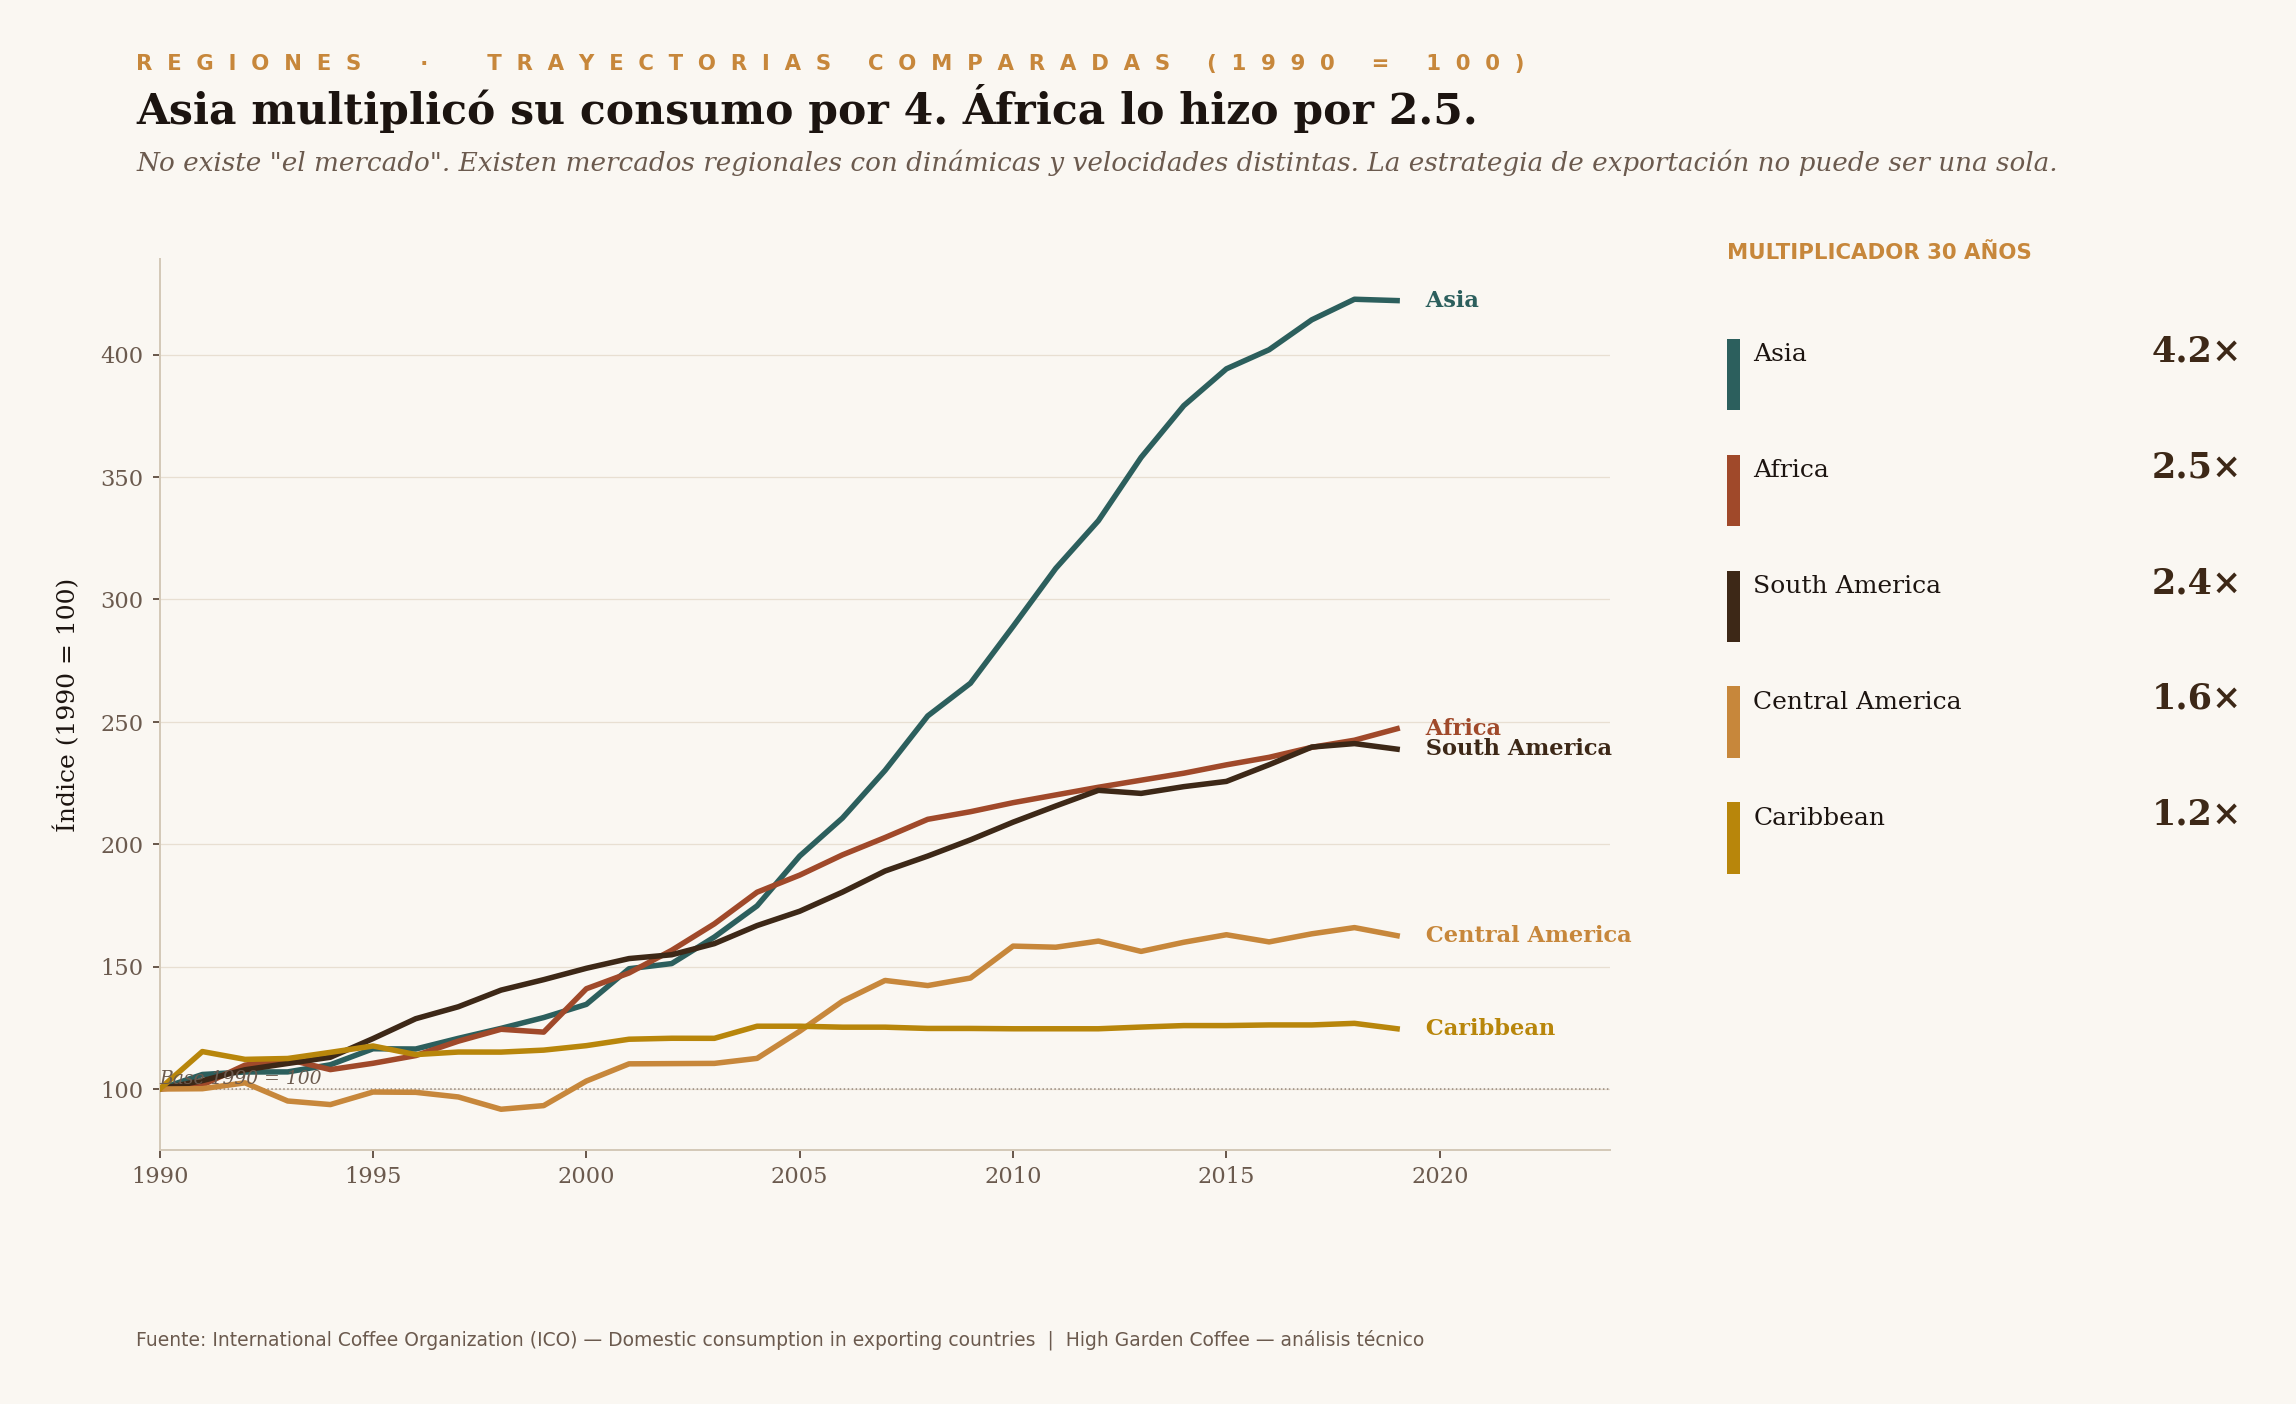

In [26]:
fig5_regional_story(long)
display(Image('figures/05_regional_story.png'))

**Lectura regional:**

- **Asia 4.2×** — el motor de crecimiento del consumo de productores
- **África 2.5×** — crecimiento moderado pero consistente (sorprendentemente similar a Sudamérica)
- **Sudamérica 2.4×** — gigantes maduros (Brasil, Colombia) sumados a su volumen base
- **Centroamérica 1.6×** — crecimiento lento y errático
- **Caribe 1.2×** — casi estancado (Cuba, Haití, Jamaica)

**Implicación estratégica:** no existe "el mercado". High Garden Coffee debe tener **al menos cuatro estrategias regionales** distintas. El playbook para Asia (donde crece el consumo doméstico = menos exportable) es opuesto al de Caribe (donde el consumo es estable = oferta exportable predecible).

---

### 4.6 Arabica y Robusta — la composición importa

**Pregunta:** ¿Cambió la composición de tipos de café consumidos en origen?

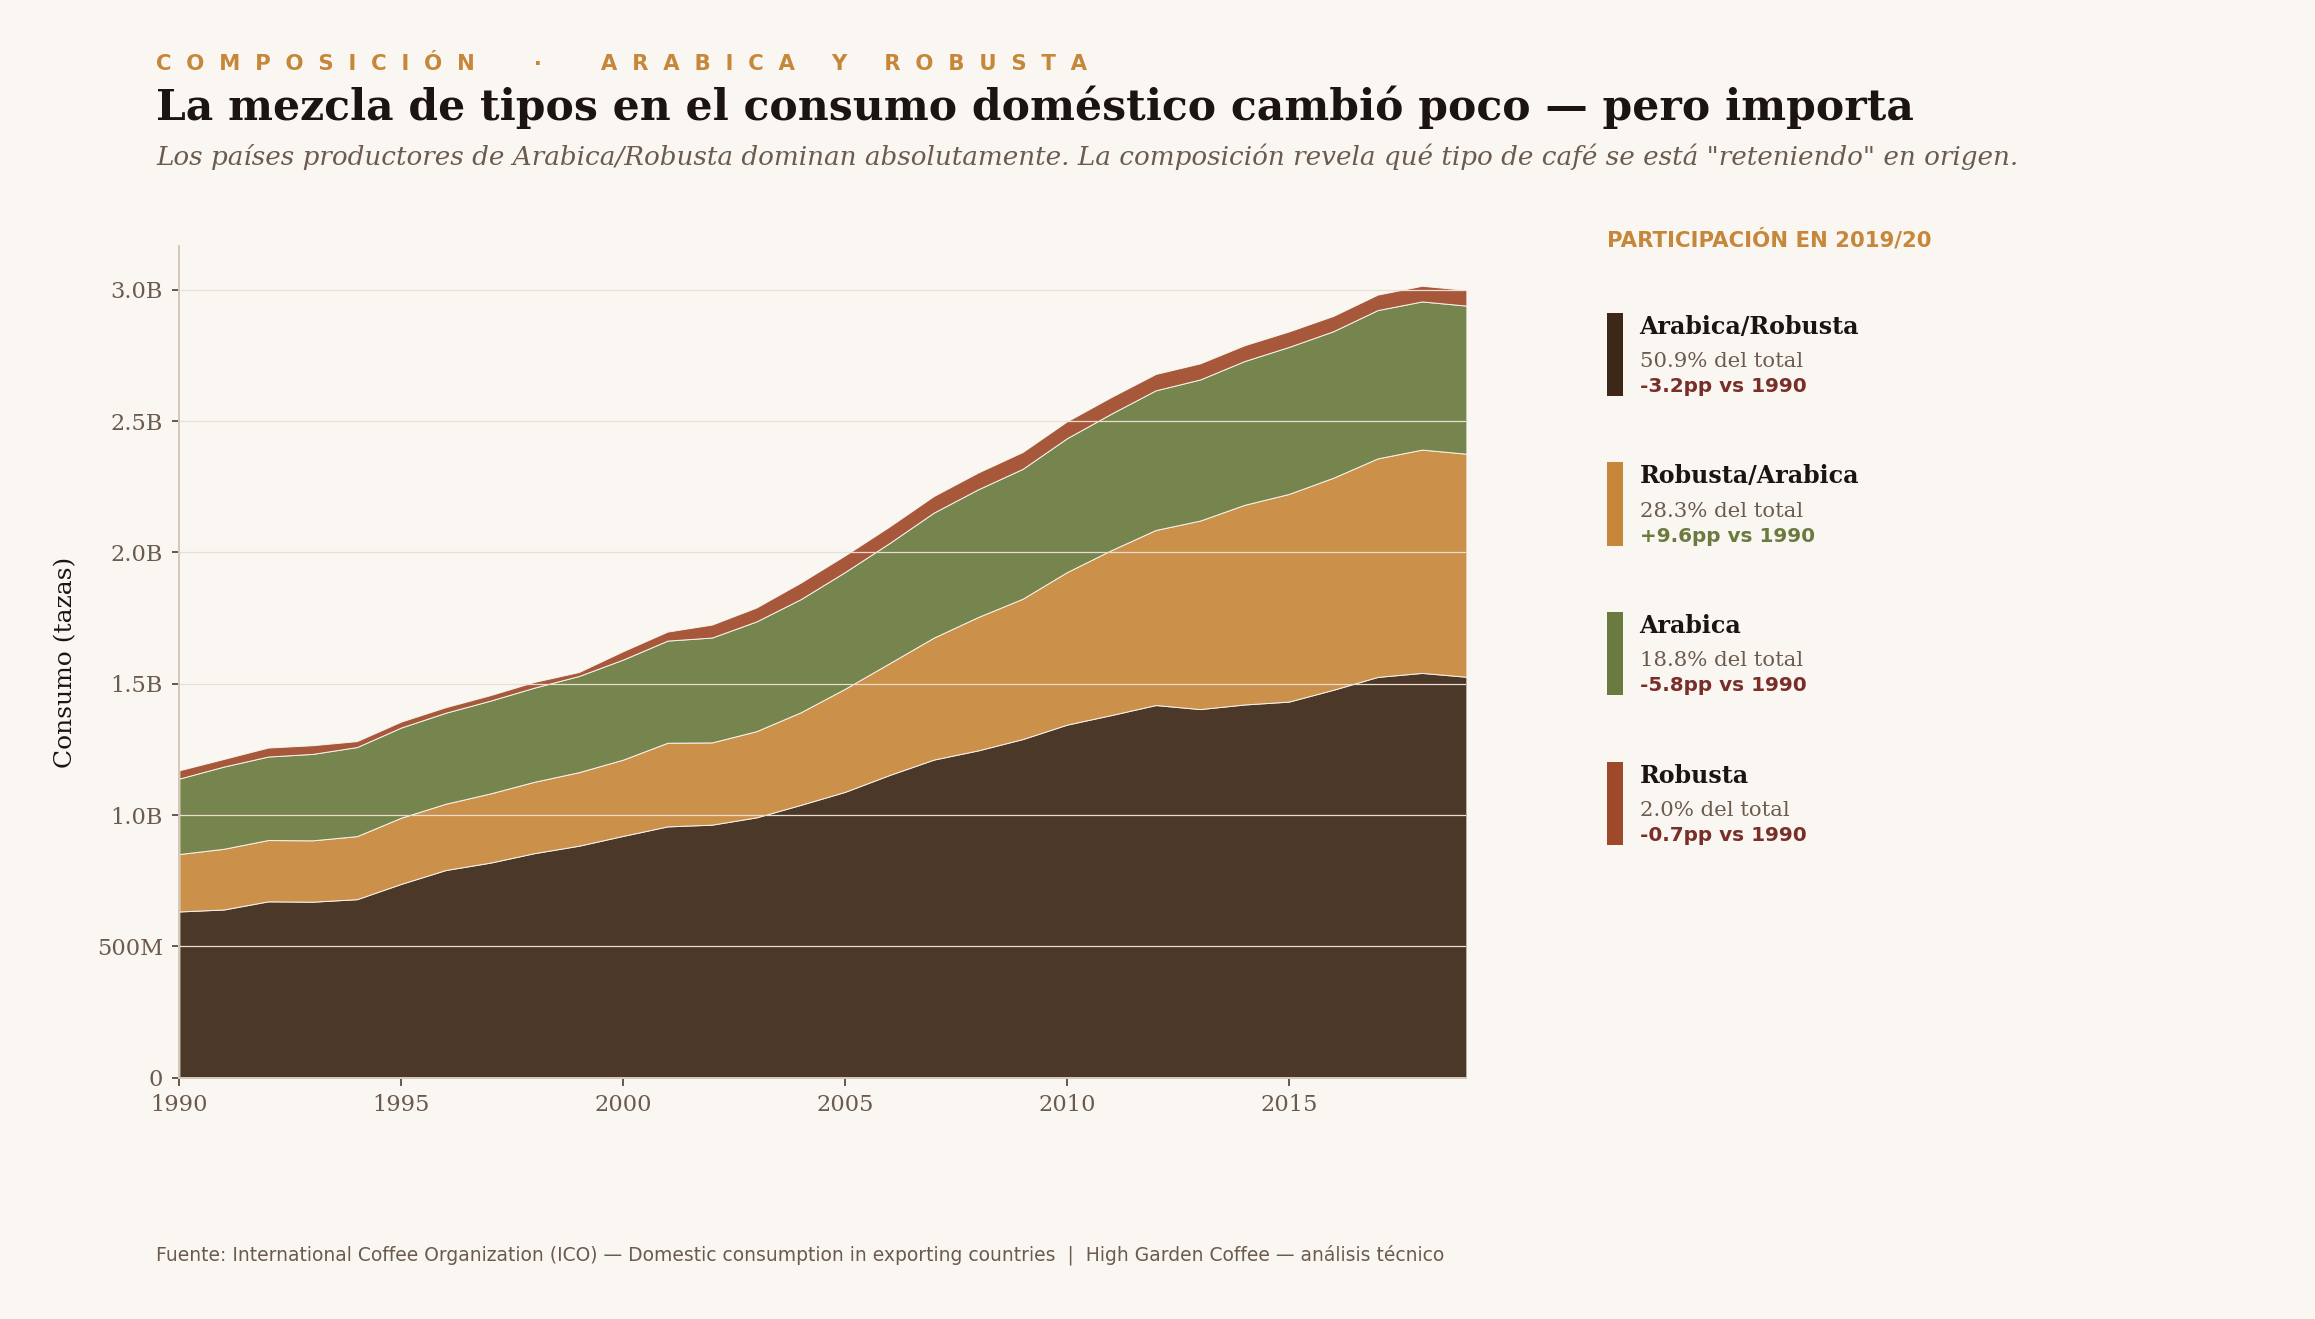

In [27]:
fig6_coffee_type(long)
display(Image('figures/06_coffee_type.png'))

**Lectura técnica:**

- **Robusta/Arabica ganó +9.6 puntos porcentuales** del total — el cambio más significativo de la composición
- Arabica pura **perdió -5.8 pp** — los países productores de Arabica pura están reteniendo proporcionalmente menos
- La predominancia de "mezclas" (Arabica/Robusta + Robusta/Arabica = 79% del total) refleja que la mayoría de productores grandes cultivan ambos tipos

**Implicación para abastecimiento:** los países que ya consumen Robusta domésticamente sugieren cosecha tipo Robusta. Esto importa porque Robusta y Arabica tienen **mercados de precios distintos** (Robusta históricamente ~50% más barata) y patrones de demanda diferentes.

---

### 4.7 Volatilidad vs tamaño — diseño técnico del forecasting

**Pregunta:** ¿Qué mercados son predecibles y cuáles son una caja negra? Esta clasificación define qué tipo de modelo usar para cada uno en el Módulo 2.

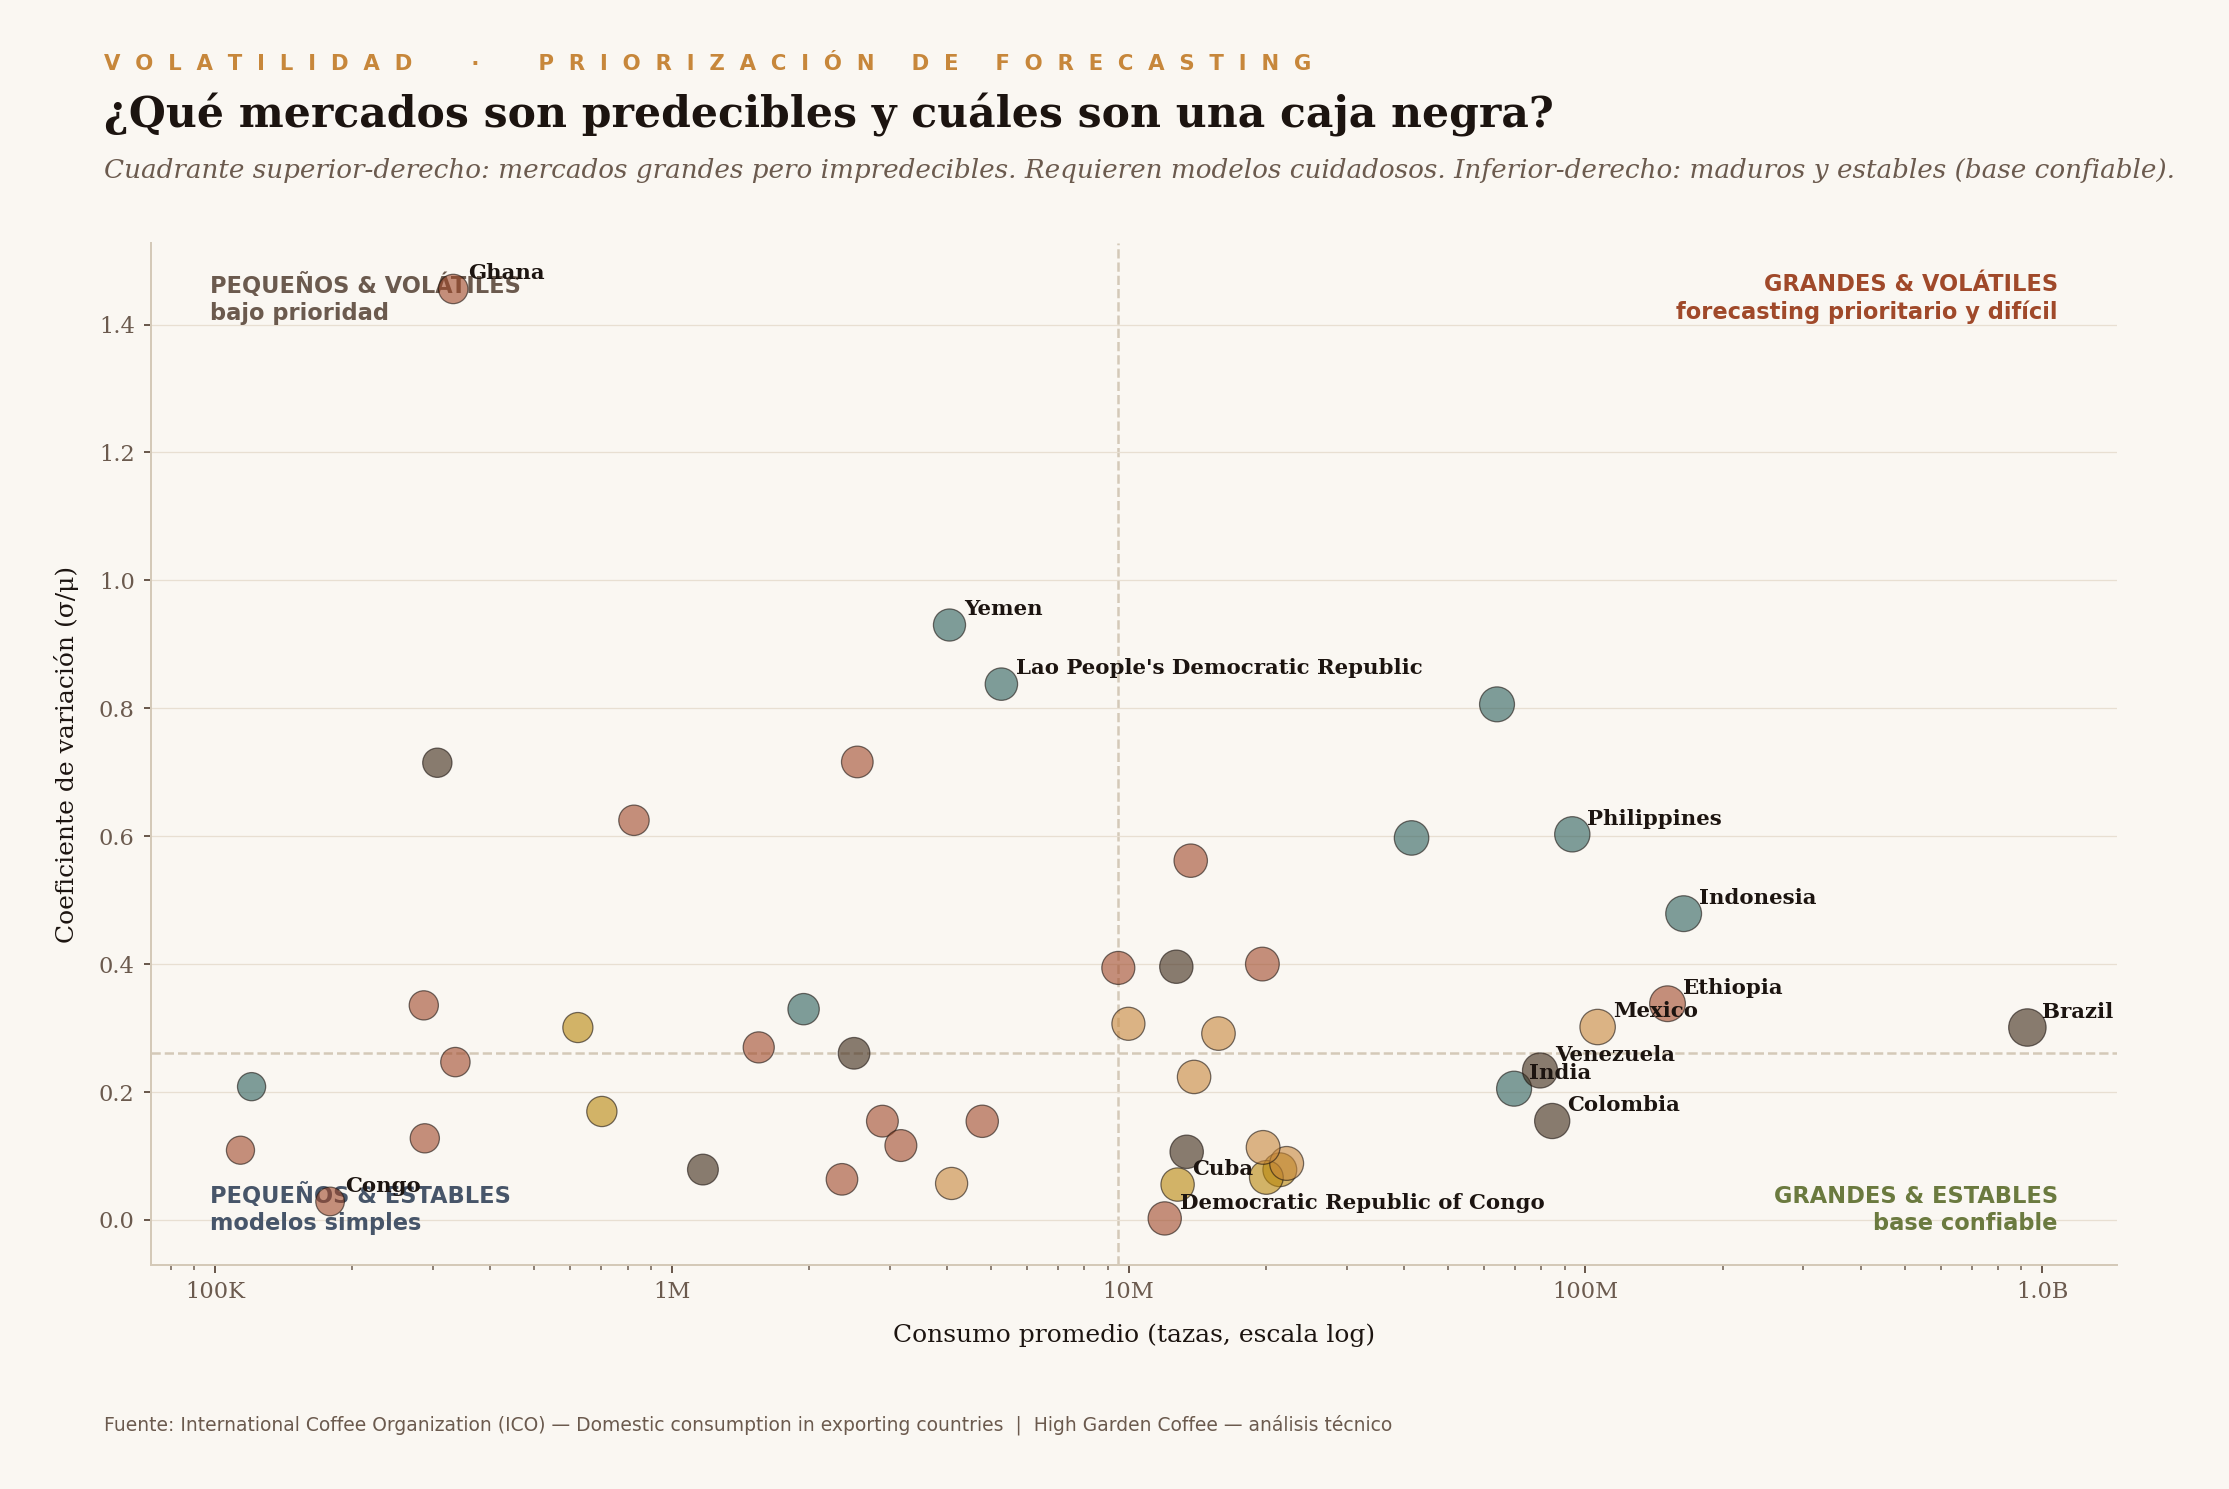

In [28]:
fig7_volatility_size(wide)
display(Image('figures/07_volatility_size.png'))

**Cuatro segmentos de modelado:**

| Segmento | Países | Modelo recomendado |
|---|---|---|
| Grandes y estables | Brasil, Colombia, India | SARIMA / Prophet simple — base confiable |
| Grandes y volátiles | Philippines, Indonesia, Ethiopia | Prophet con regresores + intervalos amplios |
| Pequeños y estables | Cuba, Costa Rica, Jamaica | Modelos simples o promedio móvil |
| Pequeños y volátiles | Yemen, Lao PDR, Ghana | Limitarse a tendencia, sin pretender precisión |

Esta segmentación es **el insumo principal del Módulo 2**. No vamos a aplicar un solo modelo global — vamos a aplicar la herramienta apropiada según el segmento.

---

## 5 · Síntesis ejecutiva y handoff al modelado

### Lo que hemos establecido en este módulo

1. **La hipótesis estratégica está blindada** — el dataset es consumo doméstico de productores (ICO), validado por composición de muestra, convenciones técnicas y documentación pública. La frase eje para la presentación final:

   > *"High Garden Coffee no necesita saber cuánto café se toma en Brasil. Necesita saber cuánto café no va a poder comprar en Brasil. Este dataset, leído correctamente, responde precisamente esa pregunta."*

2. **El dataset tiene calidad técnica impecable** — sin nulos, sin duplicados, consistencia interna perfecta. Solo 7 países requieren tratamiento por ceros.

3. **Los hallazgos cuantitativos clave:**
   - Consumo mundial de productores: **+156% en 30 años, CAGR 3.30%**
   - Concentración del mercado **creció** (HHI 2,010 → 2,226). Brasil amplió su dominancia
   - Cuatro arquetipos de país claramente distinguibles por trayectoria
   - Asia es el motor de crecimiento (4.2×), Caribbean está casi estancado (1.2×)
   - Múltiples quiebres estructurales detectables visualmente

### Handoff al Módulo 2 — Forecasting

El EDA produce tres decisiones técnicas concretas para el modelado:

| Insumo del EDA | Decisión de modelado |
|---|---|
| 4 segmentos por volatilidad/tamaño | Modelos diferenciados por segmento, no uno único |
| Quiebres estructurales detectados | Aplicar tests (Chow / changepoint) antes de modelar |
| 7 países con ceros | Tratamiento explícito (interpolación, censoring o exclusión justificada) |

### Limitaciones del dataset (declaración honesta)

- **No incluye precios** — abordamos con el Índice de Presión sobre Precios derivado
- **No incluye producción** — extensión natural con datos ICO públicos en roadmap
- **No incluye población** — análisis per cápita queda como extensión

### Datos preparados para los módulos siguientes

```
data/coffee_long.parquet      → series de tiempo país-tipo-año (1,650 filas)
data/coffee_wide.parquet      → tabla maestra enriquecida (55 países)
data/validation_report.json   → auditoría documentada
```

---

<div style="background:#FAF7F2;border-left:4px solid #C7873B;padding:16px;margin-top:24px;font-family:Georgia,serif">
<strong>Fin del Módulo 1.</strong><br>
Próximo: <em>Módulo 2 — Forecasting de demanda con detección de quiebres estructurales</em>
</div>